# Early-Exercise-Premium and Financially Constrained Models

## Residual learning for American put option pricing

**SoftUni Deep Learning Final Project**  
**Author:** Kamen Dimitrov  
**Notebook:** `05_early_exercise_premium_model.ipynb`

---

This notebook tests the central modeling proposition of the project: the neural network may learn American put values more effectively when it predicts only the value created by early exercise optionality in the American-style put option contracts rather than relearning the complete option-pricing function.

The notebook compares the direct MLP from Notebook 04 with three residual formulations:

1. an unconstrained early-exercise-premium model;
2. a non-negative early-exercise-premium model;
3. a fully constrained residual model built above the maximum of European and intrinsic value.

All models use the same five input features, frozen production splits, feature scaler, hidden-layer capacity, and evaluation framework. This isolates the effect of target design and financial constraints.

# 1. Research objective and hypotheses

The American value can be written as the sum of the European value and the early exercise premium

$$
V_A = V_E + EEP,
$$

where the early exercise premium (EEP)

$$
EEP = V_A - V_E \geq 0.
$$

The direct MLP learns $V_A/K$. The premium model instead learns

$$
y_{EEP}=\frac{V_A-V_E}{K}.
$$

The fully constrained model uses the financial floor

$$
F=\max(V_E, \max(K-S,0))
$$

and learns

$$
y_F=\frac{V_A-F}{K}.
$$

With a `Softplus` output, the reconstructed price satisfies all three lower bounds by construction.

The main outcome of this notebook is the evaluation of:

- **H2 — Premium decomposition**

A model trained to predict the early-exercise premium will achieve lower pricing error than a model trained to predict the complete American option value directly.

- **H3 — Financial constraints**

A financially constrained premium model will produce fewer non-negativity and lower-bound violations than unconstrained neural pricing models.

In [1]:
from pathlib import Path
import json
import sys
import time
from collections.abc import Mapping
import shutil
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torchinfo import summary

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.torch_datasets import (
    AmericanOptionDataset,
    FEATURE_COLUMNS,
    LoaderConfig,
    create_regression_loader,
    load_feature_scaler,
    read_parquet_components,
)

from src.data.json_export import _write_export_json

from src.evaluation.inference_benchmark import benchmark_forward_pass
from src.training.artifact_management import (
    backfill_manifest_dependencies,
    inspect_training_artifacts,
    write_training_manifest,
)

from src.evaluation.model_comparison import (
    build_model_comparison_table,
    decide_h2_premium_decomposition,
    decide_h3_financial_constraints,
    premium_error_metrics,
)

from src.evaluation.regression_metrics import regression_metrics
from src.evaluation.financial_checks import financial_bound_report
from src.models.direct_pricer import DirectAmericanPutMLP, DirectMLPConfig
from src.models.premium_pricer import PremiumAmericanPutMLP, PremiumMLPConfig
from src.training.checkpointing import load_checkpoint, save_json

from src.training.losses import (
    PremiumWeightConfig,
    WeightedSmoothL1Loss,
    apply_premium_weighting,
    fit_premium_weighting,
)

from src.training.loops import (
    TrainingConfig,
    fit_regression_model,
    predict_regression_model,
    set_global_seed,
)

from src.training.dependency_fingerprints import (
    build_training_dependencies,
    calculate_file_sha256,
)

In [2]:
DATA_DIR = PROJECT_ROOT / "data" / "generated"
DIRECT_ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "direct_mlp"
PREMIUM_ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "premium_models"
PREMIUM_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

CORE_PATHS = [
    DATA_DIR / "american_put_core.parquet",
    DATA_DIR / "american_put_boundary.parquet",
]
OOD_PATHS = {
    "high_volatility": DATA_DIR / "american_put_ood_high_volatility.parquet",
    "extreme_moneyness": DATA_DIR / "american_put_ood_extreme_moneyness.parquet",
    "long_maturity": DATA_DIR / "american_put_ood_long_maturity.parquet",
    "rate_dividend": DATA_DIR / "american_put_ood_rate_dividend.parquet",
}
DIRECT_CHECKPOINT_PATH = DIRECT_ARTIFACT_DIR / "best_direct_mlp.pt"
SCALER_PATH = DIRECT_ARTIFACT_DIR / "feature_scaler.joblib"

PRODUCTION_MANIFEST_PATH = (
    PROJECT_ROOT
    / "data"
    / "manifests"
    / "production_dataset_manifest.json"
)

# Set to True only for the first run after introducing dependency
# fingerprints to an existing training package. It updates metadata
# only and does not retrain or modify model weights.
BACKFILL_LEGACY_DEPENDENCIES = False

#This is a very important config setting!
#Keep False if model has been trained already
#Set to True if you desire to train the model
FORCE_TRAIN = False


SEED = 42
FAST_DEV_MODE = False
TRAINING_PROFILE = "fast_dev" if FAST_DEV_MODE else "full"
TRAIN_LIMIT = 100_000 if FAST_DEV_MODE else None
VALIDATION_LIMIT = 25_000 if FAST_DEV_MODE else None
TEST_LIMIT = 25_000 if FAST_DEV_MODE else None

set_global_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cpu


## 2. Data, artifact, and execution dependencies

Notebook 05 uses the same production data, feature transformation, and direct-model benchmark established in Notebook 04. The large Parquet datasets and model artifacts remain outside Git and are versioned with DVC in the project’s dedicated R2 storage.

I will specify once again that after cloning the repository, the required files should have been restored with:

```bash
dvc pull
```

The notebook expects:

* the core, boundary, and four out-of-domain Parquet components;
* the production dataset manifest;
* the Notebook 04 feature scaler;
* the trained direct-MLP checkpoint;
* any previously completed Notebook 05 premium-model package.

The Notebook 04 scaler is reused rather than fitted again. This ensures that the direct and residual models receive the same five transformed inputs and that differences in performance come from the target formulation and financial constraints rather than from a second preprocessing regime.

Before existing premium checkpoints are reused, the notebook verifies their external dependencies. The completion manifest records fingerprints for:

* the Notebook 04 feature scaler;
* the production dataset manifest;
* the exact feature-column order.

If any of these dependencies has changed, the existing premium package is treated as incompatible.

As in Notebooks 03 and 04, the user can reproduce the whole experiment with a fresh synthetic dataset and the application of the `FORCE_TRAIN` controls execution:

* `False` loads a complete and compatible premium-model package;
* `True` intentionally retrains all premium candidates;
* missing, incomplete, or incompatible artifacts trigger training even when `FORCE_TRAIN` is `False`.

`BACKFILL_LEGACY_DEPENDENCIES` is a one-time migration switch for premium artifacts created before dependency fingerprints were introduced. It updates only the completion manifest and does not modify model weights. After one successful run confirms that the existing package is compatible, it should be returned to `False`.

The train, validation, test, and OOD partitions remain unchanged from the production dataset. Training-only quantities, including premium-weighting references, are fitted exclusively on the training split.

In [3]:
required_paths = [
    *CORE_PATHS,
    *OOD_PATHS.values(),
    DIRECT_CHECKPOINT_PATH,
    SCALER_PATH,
    PRODUCTION_MANIFEST_PATH,
]
missing = [path for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Notebook 05 prerequisites are missing:\n"
        + "\n".join(f"- {path}" for path in missing)
    )

MODEL_COLUMNS = [
    "sample_id", "component", "split", *FEATURE_COLUMNS,
    "normalized_american_price", "normalized_european_price",
    "normalized_early_exercise_premium", "strike", "intrinsic_value",
    "european_price", "american_price", "moneyness", "exercise_now",
    "boundary_distance_normalized",
]

train_frame = read_parquet_components(
    CORE_PATHS, columns=MODEL_COLUMNS, split="train", row_limit=TRAIN_LIMIT
)
validation_frame = read_parquet_components(
    CORE_PATHS, columns=MODEL_COLUMNS, split="validation", row_limit=VALIDATION_LIMIT
)
test_frame = read_parquet_components(
    CORE_PATHS, columns=MODEL_COLUMNS, split="test", row_limit=TEST_LIMIT
)

for frame in (train_frame, validation_frame, test_frame):
    frame["normalized_intrinsic_value"] = frame["intrinsic_value"] / frame["strike"]
    frame["normalized_financial_floor"] = np.maximum(
        frame["normalized_european_price"], frame["normalized_intrinsic_value"]
    )
    frame["normalized_floor_residual"] = (
        frame["normalized_american_price"] - frame["normalized_financial_floor"]
    ).clip(lower=0.0)

pd.DataFrame({
    "observations": [len(train_frame), len(validation_frame), len(test_frame)],
    "exercise_rate": [
        train_frame["exercise_now"].mean(),
        validation_frame["exercise_now"].mean(),
        test_frame["exercise_now"].mean(),
    ],
}, index=["train", "validation", "test"])

,observations,exercise_rate
train,874512,0.239707
validation,187677,0.239523
test,187811,0.240454


# 3. Premium-target distribution

The premium target is structurally imbalanced because many contracts have little or no economic benefit from immediate exercise. A zero-premium predictor is therefore a mandatory baseline.

In [4]:
premium_summary = train_frame["normalized_early_exercise_premium"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)
premium_summary.to_frame("normalized premium")

,normalized premium
count,874512.000000
mean,0.013320
std,0.023708
min,0.000000
50%,0.002773
75%,0.014564
90%,0.042704
95%,0.066720
99%,0.112333
max,0.193458


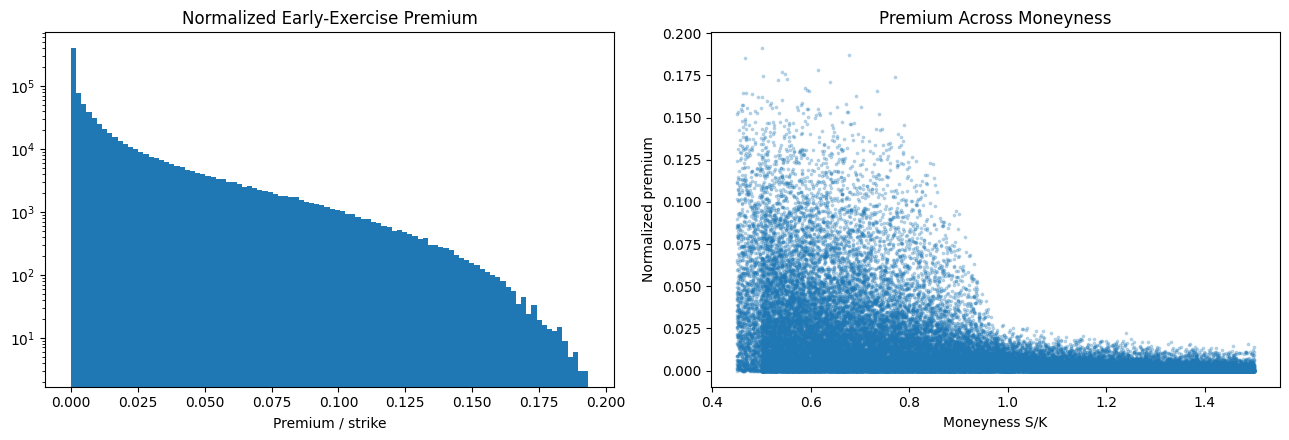

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(
    train_frame["normalized_early_exercise_premium"],
    bins=100,
)
axes[0].set_title("Normalized Early-Exercise Premium")
axes[0].set_xlabel("Premium / strike")
axes[0].set_yscale("log")

axes[1].scatter(
    train_frame["moneyness"].sample(min(50_000, len(train_frame)), random_state=SEED),
    train_frame["normalized_early_exercise_premium"].sample(
        min(50_000, len(train_frame)), random_state=SEED
    ),
    s=3,
    alpha=0.25,
)
axes[1].set_xlabel("Moneyness S/K")
axes[1].set_ylabel("Normalized premium")
axes[1].set_title("Premium Across Moneyness")
plt.tight_layout()
plt.show()

# 4. Direct-model and trivial baselines

The comparison includes:

- zero premium, equivalent to using the European value;
- mean training premium;
- the direct MLP from Notebook 04.

In [6]:
feature_scaler = load_feature_scaler(SCALER_PATH)
LOADER_CONFIG = LoaderConfig(batch_size=1024, num_workers=0, pin_memory=True, seed=SEED)

def make_dataset_loader(frame, target_column, *, weight_column=None, shuffle=False, drop_last=False):
    dataset = AmericanOptionDataset(
        frame,
        scaler=feature_scaler,
        target_column=target_column,
        weight_column=weight_column,
    )
    loader = create_regression_loader(
        dataset,
        config=LOADER_CONFIG,
        shuffle=shuffle,
        drop_last=drop_last,
    )
    return dataset, loader

direct_checkpoint = load_checkpoint(DIRECT_CHECKPOINT_PATH, map_location=DEVICE)
direct_cfg_raw = direct_checkpoint["model_config"]
direct_config = DirectMLPConfig(
    input_features=int(direct_cfg_raw["input_features"]),
    hidden_sizes=tuple(direct_cfg_raw["hidden_sizes"]),
    batch_norm_after=tuple(direct_cfg_raw["batch_norm_after"]),
    output_activation=direct_cfg_raw["output_activation"],
)
direct_model = DirectAmericanPutMLP(direct_config).to(DEVICE)
direct_model.load_state_dict(direct_checkpoint["model_state_dict"])

_, direct_test_loader = make_dataset_loader(
    test_frame, "normalized_american_price", shuffle=False
)
direct_prediction = predict_regression_model(
    direct_model, direct_test_loader, device=DEVICE
).rename(columns={"prediction": "direct_mlp"})
test_frame = test_frame.merge(
    direct_prediction[["sample_id", "direct_mlp"]],
    on="sample_id",
    validate="one_to_one",
)

mean_training_premium = float(
    train_frame["normalized_early_exercise_premium"].mean()
)
test_frame["zero_premium_baseline"] = test_frame["normalized_european_price"]
test_frame["mean_premium_baseline"] = (
    test_frame["normalized_european_price"] + mean_training_premium
)

C:\Users\kamen.dimitrov\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


# 5. Candidate definitions and weighted-loss ablation

Five candidates are trained with equal hidden-layer capacity:

1. unconstrained premium with linear output;
2. non-negative premium with `Softplus` output;
3. financial-floor residual with unweighted loss;
4. financial-floor residual with premium-magnitude weighting;
5. financial-floor residual with boundary-aware weighting.

Only the best floor-residual configuration by validation loss proceeds as the final constrained model.

**Execution control.** `FORCE_TRAIN = True` runs the full training stage and rebuilds its artifacts. After one successful run, set it to `False`; the notebook then loads the saved checkpoint and training history when the completion manifest and all required files are present. Missing or incompatible artifacts automatically trigger training.


In [7]:
CANDIDATES = {
    "unconstrained_premium": {
        "target": "normalized_early_exercise_premium",
        "residual_base": "european",
        "activation": "linear",
        "weight_mode": "unweighted",
    },
    "nonnegative_premium": {
        "target": "normalized_early_exercise_premium",
        "residual_base": "european",
        "activation": "softplus",
        "weight_mode": "unweighted",
    },
    "floor_residual_unweighted": {
        "target": "normalized_floor_residual",
        "residual_base": "financial_floor",
        "activation": "softplus",
        "weight_mode": "unweighted",
    },
    "floor_residual_magnitude": {
        "target": "normalized_floor_residual",
        "residual_base": "financial_floor",
        "activation": "softplus",
        "weight_mode": "magnitude",
    },
    "floor_residual_boundary": {
        "target": "normalized_floor_residual",
        "residual_base": "financial_floor",
        "activation": "softplus",
        "weight_mode": "boundary",
    },
}

TRAINING_CONFIG = TrainingConfig(
    epochs=100,
    learning_rate=1e-3,
    weight_decay=1e-5,
    early_stopping_patience=10,
    scheduler_patience=4,
    scheduler_factor=0.5,
    min_learning_rate=1e-6,
    gradient_clip_norm=1.0,
    mixed_precision=True,
    seed=SEED,
)
WEIGHT_CONFIG = PremiumWeightConfig()
loss_fn = WeightedSmoothL1Loss(beta=1.0)

In [8]:
print("Direct MLP from Notebook 04")
summary(
    direct_model,
    input_size=(1, len(FEATURE_COLUMNS)),
    device=DEVICE,
)

print("\nPremium / residual MLP")
representative_premium_model = PremiumAmericanPutMLP(
    PremiumMLPConfig(
        input_features=len(FEATURE_COLUMNS),
        hidden_sizes=(128, 128, 64, 32),
        batch_norm_after=(0, 1),
        output_activation="softplus",
    )
).to(DEVICE)

summary(
    representative_premium_model,
    input_size=(1, len(FEATURE_COLUMNS)),
    device=DEVICE,
)

Direct MLP from Notebook 04

Premium / residual MLP


Layer (type:depth-idx)                   Output Shape              Param #
PremiumAmericanPutMLP                    [1, 1]                    --
├─Sequential: 1-1                        [1, 1]                    --
│    └─Linear: 2-1                       [1, 128]                  768
│    └─BatchNorm1d: 2-2                  [1, 128]                  256
│    └─SiLU: 2-3                         [1, 128]                  --
│    └─Linear: 2-4                       [1, 128]                  16,512
│    └─BatchNorm1d: 2-5                  [1, 128]                  256
│    └─SiLU: 2-6                         [1, 128]                  --
│    └─Linear: 2-7                       [1, 64]                   8,256
│    └─SiLU: 2-8                         [1, 64]                   --
│    └─Linear: 2-9                       [1, 32]                   2,080
│    └─SiLU: 2-10                        [1, 32]                   --
│    └─Linear: 2-11                      [1, 1]                    33
│ 

In [9]:
TRAINING_MANIFEST_PATH = PREMIUM_ARTIFACT_DIR / "training_complete.json"
TRAINING_CONFIG_PATH = PREMIUM_ARTIFACT_DIR / "training_config.json"
CANDIDATE_CONFIG_PATH = PREMIUM_ARTIFACT_DIR / "candidate_config.json"
CANDIDATE_SUMMARY_PATH = PREMIUM_ARTIFACT_DIR / "candidate_training_summary.csv"

candidate_checkpoint_paths = {
    name: PREMIUM_ARTIFACT_DIR / f"best_{name}.pt"
    for name in CANDIDATES
}
candidate_history_paths = {
    name: PREMIUM_ARTIFACT_DIR / f"training_history_{name}.csv"
    for name in CANDIDATES
}

required_training_outputs = [
    TRAINING_CONFIG_PATH,
    CANDIDATE_CONFIG_PATH,
    CANDIDATE_SUMMARY_PATH,
    *candidate_checkpoint_paths.values(),
    *candidate_history_paths.values(),
]

current_training_dependencies = build_training_dependencies(
    project_root=PROJECT_ROOT,
    feature_scaler_path=SCALER_PATH,
    production_manifest_path=PRODUCTION_MANIFEST_PATH,
    feature_columns=FEATURE_COLUMNS,
)

if backfill_manifest_dependencies(
    TRAINING_MANIFEST_PATH,
    current_training_dependencies,
    enabled=BACKFILL_LEGACY_DEPENDENCIES,
    force_train=FORCE_TRAIN,
):
    print(
        "Added dependency fingerprints to the "
        "existing training manifest."
    )

training_outputs_available, availability_reason = inspect_training_artifacts(
    TRAINING_MANIFEST_PATH,
    required_training_outputs,
    expected_notebook="05_early_exercise_premium_model",
    expected_profile=TRAINING_PROFILE,
    expected_dependencies=current_training_dependencies,
)
RUN_TRAINING = FORCE_TRAIN or not training_outputs_available

print(f"Force training:             {FORCE_TRAIN}")
print(f"Training outputs available: {training_outputs_available}")
print(f"Decision:                   {'train' if RUN_TRAINING else 'load'}")
print(f"Artifact check:             {availability_reason}")

candidate_results = {}
if RUN_TRAINING:
    TRAINING_MANIFEST_PATH.unlink(missing_ok=True)
training_started = time.perf_counter() if RUN_TRAINING else None

for candidate_name, specification in CANDIDATES.items():
    print(
        f"\n=== {candidate_name}: "
        f"{'training' if RUN_TRAINING else 'loading saved output'} ==="
    )

    target_column = specification["target"]
    checkpoint_path = candidate_checkpoint_paths[candidate_name]
    history_path = candidate_history_paths[candidate_name]

    if RUN_TRAINING:
        weight_mode = specification["weight_mode"]
        train_work = train_frame.copy()
        validation_work = validation_frame.copy()
        weight_column = None

        fitted_weighting = fit_premium_weighting(
            train_work,
            target_column=target_column,
            mode=weight_mode,
            config=WEIGHT_CONFIG,
        )
        if weight_mode != "unweighted":
            weight_column = "training_weight"
            train_work[weight_column] = apply_premium_weighting(
                train_work,
                fitted=fitted_weighting,
            )
            validation_work[weight_column] = apply_premium_weighting(
                validation_work,
                fitted=fitted_weighting,
            )

        _, train_loader = make_dataset_loader(
            train_work,
            target_column,
            weight_column=weight_column,
            shuffle=True,
            drop_last=True,
        )
        _, validation_loader = make_dataset_loader(
            validation_work,
            target_column,
            weight_column=weight_column,
            shuffle=False,
        )

        model_config = PremiumMLPConfig(
            input_features=len(FEATURE_COLUMNS),
            hidden_sizes=(128, 128, 64, 32),
            batch_norm_after=(0, 1),
            output_activation=specification["activation"],
            residual_base=specification["residual_base"],
        )
        model = PremiumAmericanPutMLP(model_config).to(DEVICE)

        history = fit_regression_model(
            model,
            train_loader,
            validation_loader,
            loss_fn=loss_fn,
            device=DEVICE,
            checkpoint_path=checkpoint_path,
            config=TRAINING_CONFIG,
            model_config={
                **model_config.to_dict(),
                "target_column": target_column,
                "weighting": fitted_weighting.to_dict(),
            },
        )
        history.to_csv(history_path, index=False)
    else:
        history = pd.read_csv(history_path)

    checkpoint = load_checkpoint(checkpoint_path, map_location="cpu")
    best_validation_loss = float(
        checkpoint.get(
            "best_validation_loss",
            history["validation_loss"].min(),
        )
    )
    best_epoch = int(
        checkpoint.get(
            "epoch",
            history.loc[history["validation_loss"].idxmin(), "epoch"],
        )
    )

    saved_metadata = checkpoint.get("model_config")

    if not isinstance(saved_metadata, dict):
        raise ValueError(
            f"Checkpoint for {candidate_name!r} "
            "does not contain valid model_config metadata."
        )
    
    required_metadata = {
        "input_features",
        "hidden_sizes",
        "batch_norm_after",
        "output_activation",
        "residual_base",
        "target_column",
        "weighting",
    }

    missing_metadata = sorted(
        required_metadata.difference(saved_metadata)
    )

    if missing_metadata:
        raise ValueError(
            f"Checkpoint for {candidate_name!r} is missing metadata: "
            f"{missing_metadata}"
        )

    candidate_results[candidate_name] = {
        "checkpoint_path": checkpoint_path,
        "best_validation_loss": best_validation_loss,
        "best_epoch": best_epoch,
        "checkpoint_metadata": saved_metadata,
        "history": history,
    }

candidate_summary = pd.DataFrame(
    {
        name: {
            "best_validation_loss": result["best_validation_loss"],
            "best_epoch": result["best_epoch"],
        }
        for name, result in candidate_results.items()
    }
).T.sort_values("best_validation_loss")

if RUN_TRAINING:
    training_runtime_seconds = time.perf_counter() - training_started
    candidate_summary.to_csv(CANDIDATE_SUMMARY_PATH)
    save_json(TRAINING_CONFIG.to_dict(), TRAINING_CONFIG_PATH)
    save_json(CANDIDATES, CANDIDATE_CONFIG_PATH)

    write_training_manifest(
        TRAINING_MANIFEST_PATH,
        {
            "status": "complete",
            "notebook": "05_early_exercise_premium_model",
            "training_profile": TRAINING_PROFILE,
            "dependencies": current_training_dependencies,
            "requested_epochs_per_candidate": int(TRAINING_CONFIG.epochs),
            "candidate_count": len(CANDIDATES),
            "training_runtime_seconds": float(training_runtime_seconds),
            "candidates": {
                name: {
                    "best_epoch": int(result["best_epoch"]),
                    "best_validation_loss": float(
                        result["best_validation_loss"]
                    ),
                    "checkpoint": result["checkpoint_path"].name,
                    "history": candidate_history_paths[name].name,
                }
                for name, result in candidate_results.items()
            },
        },
    )

candidate_summary

Force training:             False
Training outputs available: True
Decision:                   load
Artifact check:             complete compatible package found

=== unconstrained_premium: loading saved output ===

=== nonnegative_premium: loading saved output ===

=== floor_residual_unweighted: loading saved output ===

=== floor_residual_magnitude: loading saved output ===

=== floor_residual_boundary: loading saved output ===


,best_validation_loss,best_epoch
floor_residual_unweighted,2.282188e-08,42.0
floor_residual_boundary,3.834845e-08,30.0
floor_residual_magnitude,4.087623e-08,35.0
nonnegative_premium,6.373555e-08,42.0
unconstrained_premium,6.527215e-08,57.0


# 6. Test-set reconstruction and model comparison

Residual predictions are converted back to normalized American prices before evaluation. The comparison therefore measures the economically relevant final price, not only the residual target.

In [10]:
def predict_candidate(candidate_name, frame):
    """Load and evaluate a candidate using saved checkpoint metadata."""

    result = candidate_results[candidate_name]

    checkpoint = load_checkpoint(
        result["checkpoint_path"],
        map_location=DEVICE,
    )

    metadata = checkpoint.get("model_config")

    if not isinstance(metadata, dict):
        raise ValueError(
            f"Checkpoint for {candidate_name!r} "
            "does not contain valid model_config metadata."
        )

    required_fields = {
        "input_features",
        "hidden_sizes",
        "batch_norm_after",
        "output_activation",
        "residual_base",
        "target_column",
    }

    missing_fields = sorted(
        required_fields.difference(metadata)
    )

    if missing_fields:
        raise ValueError(
            f"Checkpoint for {candidate_name!r} "
            f"is missing metadata: {missing_fields}"
        )

    target_column = str(
        metadata["target_column"]
    )
    residual_base = str(
        metadata["residual_base"]
    )

    if target_column not in frame.columns:
        raise ValueError(
            f"Evaluation frame is missing the saved target column "
            f"{target_column!r} for {candidate_name!r}."
        )

    if residual_base not in {
        "european",
        "financial_floor",
    }:
        raise ValueError(
            f"Unsupported saved residual base: {residual_base!r}"
        )

    model_config = PremiumMLPConfig(
        input_features=int(
            metadata["input_features"]
        ),
        hidden_sizes=tuple(
            metadata["hidden_sizes"]
        ),
        batch_norm_after=tuple(
            metadata["batch_norm_after"]
        ),
        output_activation=str(
            metadata["output_activation"]
        ),
        residual_base=residual_base,
    )

    model = PremiumAmericanPutMLP(
        model_config
    ).to(DEVICE)

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    model.eval()

    _, loader = make_dataset_loader(
        frame,
        target_column,
        shuffle=False,
    )

    predicted = predict_regression_model(
        model,
        loader,
        device=DEVICE,
    )

    merged = frame[
        [
            "sample_id",
            "normalized_european_price",
            "normalized_financial_floor",
        ]
    ].merge(
        predicted[
            [
                "sample_id",
                "prediction",
            ]
        ],
        on="sample_id",
        validate="one_to_one",
    )

    base_column_by_type = {
        "european": "normalized_european_price",
        "financial_floor": "normalized_financial_floor",
    }

    base_column = base_column_by_type[
        residual_base
    ]

    merged["normalized_price_prediction"] = (
        merged[base_column]
        + merged["prediction"]
    )

    merged["normalized_premium_prediction"] = (
        merged["normalized_price_prediction"]
        - merged["normalized_european_price"]
    )

    return model, merged

# Select the floor-residual candidate on one common metric:
# unweighted reconstructed American-price MAE on the validation split.
#
# The training validation losses are not directly comparable because each
# weighting specification evaluates a different weighted objective.

floor_candidates = [
    name
    for name, result in candidate_results.items()
    if result["checkpoint_metadata"]["residual_base"]
    == "financial_floor"
]

floor_validation_rows = []

for candidate_name in floor_candidates:
    _, validation_predictions = predict_candidate(
        candidate_name,
        validation_frame,
    )

    validation_evaluation = validation_frame[
        [
            "sample_id",
            "normalized_american_price",
            "strike",
        ]
    ].merge(
        validation_predictions[
            [
                "sample_id",
                "normalized_price_prediction",
            ]
        ],
        on="sample_id",
        validate="one_to_one",
    )

    normalized_metrics = regression_metrics(
        validation_evaluation[
            "normalized_american_price"
        ],
        validation_evaluation[
            "normalized_price_prediction"
        ],
    )

    actual_price = (
        validation_evaluation[
            "normalized_american_price"
        ]
        * validation_evaluation["strike"]
    )
    predicted_price = (
        validation_evaluation[
            "normalized_price_prediction"
        ]
        * validation_evaluation["strike"]
    )

    price_metrics = regression_metrics(
        actual_price,
        predicted_price,
    )

    floor_validation_rows.append(
        {
            "candidate": candidate_name,
            "weight_mode": (
                candidate_results[candidate_name]
                ["checkpoint_metadata"]
                ["weighting"]
                ["mode"]
            ),
            "normalized_price_mae": (
                normalized_metrics["mae"]
            ),
            "normalized_price_rmse": (
                normalized_metrics["rmse"]
            ),
            "price_mae": price_metrics["mae"],
            "price_rmse": price_metrics["rmse"],
            "mean_price_error": (
                price_metrics["mean_error"]
            ),
            "maximum_price_error": (
                price_metrics["max_absolute_error"]
            ),
        }
    )

floor_validation_comparison = (
    pd.DataFrame(floor_validation_rows)
    .set_index("candidate")
    .sort_values(
        [
            "normalized_price_mae",
            "normalized_price_rmse",
        ]
    )
)

best_floor_candidate = (
    floor_validation_comparison.index[0]
)

display(floor_validation_comparison)

print(
    "Selected floor candidate: "
    f"{best_floor_candidate}"
)
print(
    "Selection metric: unweighted validation "
    "American-price MAE"
)
selected_names = [
    "unconstrained_premium",
    "nonnegative_premium",
    best_floor_candidate,
]
selected_models = {}
for name in selected_names:
    model, predictions = predict_candidate(name, test_frame)
    selected_models[name] = model
    test_frame = test_frame.merge(
        predictions[["sample_id", "normalized_price_prediction", "normalized_premium_prediction"]].rename(
            columns={
                "normalized_price_prediction": name,
                "normalized_premium_prediction": f"{name}_premium",
            }
        ),
        on="sample_id",
        validate="one_to_one",
    )

comparison = build_model_comparison_table(
    test_frame,
    actual_column="normalized_american_price",
    prediction_columns={
        "Zero premium": "zero_premium_baseline",
        "Mean premium": "mean_premium_baseline",
        "Direct MLP": "direct_mlp",
        "Unconstrained premium": "unconstrained_premium",
        "Non-negative premium": "nonnegative_premium",
        "Constrained floor residual": best_floor_candidate,
    },
)
comparison

,weight_mode,normalized_price_mae,normalized_price_rmse,price_mae,price_rmse,mean_price_error,maximum_price_error
candidate,,,,,,,
floor_residual_unweighted,unweighted,0.000103,0.000214,0.010252,0.021364,-0.001412,0.460190
floor_residual_magnitude,magnitude,0.000125,0.000241,0.012497,0.024082,0.000250,0.375435
floor_residual_boundary,boundary,0.000131,0.000246,0.013067,0.024560,-0.002229,0.449515


Selected floor candidate: floor_residual_unweighted
Selection metric: unweighted validation American-price MAE


,observations,mae,rmse,median_absolute_error,max_absolute_error,mean_error,r2,within_0.001,within_0.005,within_0.01,within_0.05,negative_price_count,negative_price_rate,below_intrinsic_count,below_intrinsic_rate,below_european_count,below_european_rate,total_bound_violations
model,,,,,,,,,,,,,,,,,,
Constrained floor residual,187811.0,0.000102,0.000213,0.000046,0.004641,-0.000014,0.999998,0.992860,1.000000,1.000000,1.000000,0,0.000000,0,0.000000,0,0.000000,0
Non-negative premium,187811.0,0.000205,0.000356,0.000115,0.006268,0.000028,0.999995,0.975859,0.999925,1.000000,1.000000,0,0.000000,23711,0.126249,0,0.000000,23711
Unconstrained premium,187811.0,0.000220,0.000359,0.000142,0.007582,-0.000017,0.999995,0.977951,0.999867,1.000000,1.000000,2728,0.014525,31526,0.167860,25970,0.138277,60224
Direct MLP,187811.0,0.000782,0.001146,0.000548,0.019201,-0.000128,0.999950,0.741927,0.995107,0.999766,1.000000,0,0.000000,32993,0.175671,25817,0.137463,58810
Zero premium,187811.0,0.013398,0.027384,0.002710,0.188955,-0.013398,0.971395,0.390595,0.583757,0.690039,0.917438,0,0.000000,57780,0.307650,0,0.000000,57780
Mean premium,187811.0,0.015921,0.023883,0.012820,0.175635,-0.000079,0.978242,0.023375,0.122341,0.292597,0.943651,0,0.000000,38540,0.205206,0,0.000000,38540


## Model comparison result

The unweighted floor-residual model was selected using the common validation metric, with an MAE of 0.0103 price units. On the test set, its MAE is 0.0102, approximately 87% lower than the direct MLP, while producing no financial-bound violations.

# 7. Premium-specific evaluation

Aggregate price error can conceal a model that simply predicts zero premium. The premium itself is therefore evaluated separately, including on observations with economically material premiums.

In [11]:
positive_training_premium = train_frame.loc[
    train_frame["normalized_early_exercise_premium"] > 0.0,
    "normalized_early_exercise_premium",
]
material_threshold = float(positive_training_premium.quantile(0.75))

premium_rows = []
for name in ["unconstrained_premium", "nonnegative_premium", best_floor_candidate]:
    metrics = premium_error_metrics(
        test_frame["normalized_early_exercise_premium"],
        test_frame[f"{name}_premium"],
        material_threshold=material_threshold,
    )
    premium_rows.append({"model": name, **metrics})

premium_comparison = pd.DataFrame(premium_rows).set_index("model")
premium_comparison

,observations,mae,rmse,median_absolute_error,max_absolute_error,mean_error,r2,within_0.001,within_0.005,within_0.01,within_0.05,material_threshold,material_observations,negative_prediction_rate,material_mae,material_mean_relative_error
model,,,,,,,,,,,,,,,,
unconstrained_premium,187811.0,0.000220,0.000359,0.000142,0.007582,-0.000017,0.999774,0.977951,0.999867,1.0,1.0,0.017766,41500.0,0.138277,0.000352,0.008920
nonnegative_premium,187811.0,0.000205,0.000356,0.000115,0.006268,0.000028,0.999778,0.975859,0.999925,1.0,1.0,0.017766,41500.0,0.000000,0.000361,0.008823
floor_residual_unweighted,187811.0,0.000102,0.000213,0.000046,0.004641,-0.000014,0.999921,0.992860,1.000000,1.0,1.0,0.017766,41500.0,0.000000,0.000125,0.004150


## Premium-specific result

The floor-residual model also remains strongest for material premiums above 1.7766 price units. Its MAE in this subset is 0.0125 price units, with a mean relative error of 0.42%. The improvement is therefore not driven only by the large number of small-premium observations.

# 8. Loss-ablation interpretation

The three floor-residual variants isolate the effect of weighting. Their validation histories should be interpreted together with final price accuracy, premium accuracy, and boundary-region performance. A lower weighted validation loss does not automatically imply a lower unweighted test MAE.

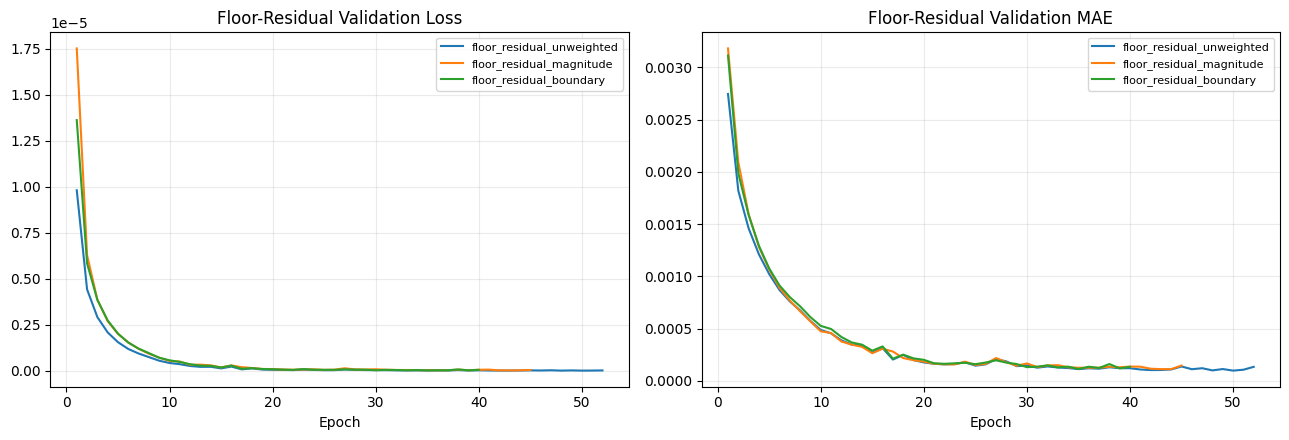

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name in floor_candidates:
    history = candidate_results[name]["history"]
    axes[0].plot(history["epoch"], history["validation_loss"], label=name)
    axes[1].plot(history["epoch"], history["validation_mae"], label=name)
axes[0].set_title("Floor-Residual Validation Loss")
axes[1].set_title("Floor-Residual Validation MAE")
for axis in axes:
    axis.set_xlabel("Epoch")
    axis.grid(alpha=0.25)
    axis.legend(fontsize=8)
plt.tight_layout()
plt.show()

# 9. Segmented and boundary-region analysis

The constrained model is evaluated across exercise status, moneyness, and proximity to the exercise boundary. This determines whether aggregate accuracy is achieved at the expense of the economically difficult transition region.

In [13]:
test_frame["exercise_region"] = np.where(
    test_frame["exercise_now"], "exercise", "continue"
)
test_frame["boundary_bucket"] = pd.cut(
    test_frame["boundary_distance_normalized"],
    bins=[-np.inf, 0.001, 0.005, 0.01, 0.05, np.inf],
    labels=["very close", "close", "near", "moderate", "far"],
)
test_frame["moneyness_bucket"] = pd.cut(
    test_frame["moneyness"],
    bins=[0.0, 0.75, 0.90, 1.10, 1.25, np.inf],
    labels=["deep ITM", "ITM", "near ATM", "OTM", "deep OTM"],
)

segmented_rows = []
for model_name, column in {
    "Direct MLP": "direct_mlp",
    "Non-negative premium": "nonnegative_premium",
    "Constrained floor residual": best_floor_candidate,
}.items():
    for segment_name in ("exercise_region", "boundary_bucket", "moneyness_bucket"):
        for segment, group in test_frame.groupby(segment_name, observed=True):
            segmented_rows.append({
                "model": model_name,
                "segment_type": segment_name,
                "segment": str(segment),
                **regression_metrics(
                    group["normalized_american_price"], group[column]
                ),
            })

segmented_results = pd.DataFrame(segmented_rows)
display(segmented_results)

,model,segment_type,segment,observations,mae,rmse,median_absolute_error,max_absolute_error,mean_error,r2,within_0.001,within_0.005,within_0.01,within_0.05
0,Direct MLP,exercise_region,continue,142651.0,0.000728,0.001073,5.177534e-04,0.019201,3.586543e-05,0.999949,0.770741,0.995745,0.999713,1.0
1,Direct MLP,exercise_region,exercise,45160.0,0.000951,0.001348,6.814337e-04,0.014359,-6.468806e-04,0.999894,0.650908,0.993091,0.999934,1.0
2,Direct MLP,boundary_bucket,very close,59673.0,0.000906,0.001301,6.270226e-04,0.014359,-3.612224e-04,0.999944,0.673655,0.993464,0.999950,1.0
3,Direct MLP,boundary_bucket,close,14000.0,0.001057,0.001553,7.078845e-04,0.011809,7.384574e-04,0.999924,0.622500,0.983643,0.999571,1.0
4,Direct MLP,boundary_bucket,near,7112.0,0.000916,0.001439,5.857650e-04,0.014937,3.177449e-04,0.999935,0.682649,0.988048,0.998453,1.0
5,Direct MLP,boundary_bucket,moderate,33585.0,0.000869,0.001256,6.415583e-04,0.019201,-2.096943e-04,0.999943,0.691767,0.994313,0.999315,1.0
6,Direct MLP,boundary_bucket,far,73441.0,0.000575,0.000774,4.557861e-04,0.011382,-1.102556e-04,0.999958,0.848845,0.999673,0.999986,1.0
7,Direct MLP,moneyness_bucket,deep ITM,65461.0,0.000825,0.001090,6.478696e-04,0.011382,-3.897527e-04,0.999802,0.684239,0.999236,0.999985,1.0
8,Direct MLP,moneyness_bucket,ITM,29422.0,0.000863,0.001183,6.279193e-04,0.010490,-1.320084e-04,0.999751,0.683128,0.998063,0.999966,1.0
9,Direct MLP,moneyness_bucket,near ATM,32521.0,0.000946,0.001537,5.644748e-04,0.019201,-9.629978e-05,0.999751,0.724732,0.980136,0.999231,1.0


## Segmented performance

The constrained floor model has the lowest MAE in every exercise, boundary-distance, and moneyness segment. Its MAE is 0.0031 price units in the exercise region and 0.0052 for observations very close to the exercise boundary. The aggregate result is therefore not hiding weaker performance in the financially difficult regions.

# 10. Out-of-domain evaluation

The selected residual models are evaluated without retraining on all four out-of-domain components. Feature scaling remains frozen from Notebook 04.

In [14]:
ood_rows = []
ood_financial_rows = []

for ood_name, path in OOD_PATHS.items():
    frame = read_parquet_components(
        [path],
        columns=MODEL_COLUMNS,
        split=None,
    )

    frame["normalized_intrinsic_value"] = (
        frame["intrinsic_value"]
        / frame["strike"]
    )
    frame["normalized_financial_floor"] = np.maximum(
        frame["normalized_european_price"],
        frame["normalized_intrinsic_value"],
    )
    frame["normalized_floor_residual"] = (
        frame["normalized_american_price"]
        - frame["normalized_financial_floor"]
    ).clip(lower=0.0)

    # Zero-premium baseline:
    # American price is approximated by the European price.
    frame["zero_premium_baseline"] = (
        frame["normalized_european_price"]
    )

    _, direct_loader = make_dataset_loader(
        frame,
        "normalized_american_price",
        shuffle=False,
    )
    direct_pred = predict_regression_model(
        direct_model,
        direct_loader,
        device=DEVICE,
    )

    frame = frame.merge(
        direct_pred[
            ["sample_id", "prediction"]
        ].rename(
            columns={
                "prediction": "Direct MLP",
            }
        ),
        on="sample_id",
        validate="one_to_one",
    )

    for candidate_name in [
        "nonnegative_premium",
        best_floor_candidate,
    ]:
        _, prediction = predict_candidate(
            candidate_name,
            frame,
        )

        frame = frame.merge(
            prediction[
                [
                    "sample_id",
                    "normalized_price_prediction",
                ]
            ].rename(
                columns={
                    "normalized_price_prediction": (
                        candidate_name
                    ),
                }
            ),
            on="sample_id",
            validate="one_to_one",
        )

    model_columns = {
        "Zero premium": "zero_premium_baseline",
        "Direct MLP": "Direct MLP",
        "Non-negative premium": (
            "nonnegative_premium"
        ),
        "Constrained floor residual": (
            best_floor_candidate
        ),
    }

    for model_name, column in model_columns.items():
        ood_rows.append(
            {
                "ood_set": ood_name,
                "model": model_name,
                **regression_metrics(
                    frame[
                        "normalized_american_price"
                    ],
                    frame[column],
                ),
            }
        )

        financial_report = financial_bound_report(
            frame,
            normalized_prediction_column=column,
        ).copy()

        financial_report.insert(
            0,
            "model",
            model_name,
        )
        financial_report.insert(
            0,
            "ood_set",
            ood_name,
        )

        ood_financial_rows.append(
            financial_report
        )


ood_results = (
    pd.DataFrame(ood_rows)
    .set_index(["ood_set", "model"])
)

ood_financial_results = (
    pd.concat(
        ood_financial_rows,
        ignore_index=True,
    )
    .set_index(
        ["ood_set", "model", "check"]
    )
)

display(ood_results)
display(ood_financial_results)

observations       mae  \
ood_set           model                                                
high_volatility   Zero premium                     50000.0  0.006887   
                  Direct MLP                       50000.0  0.009221   
                  Non-negative premium             50000.0  0.000509   
                  Constrained floor residual       50000.0  0.000568   
extreme_moneyness Zero premium                     50000.0  0.016067   
                  Direct MLP                       50000.0  0.011993   
                  Non-negative premium             50000.0  0.000883   
                  Constrained floor residual       50000.0  0.000118   
long_maturity     Zero premium                     50000.0  0.022406   
                  Direct MLP                       50000.0  0.046026   
                  Non-negative premium             50000.0  0.009383   
                  Constrained floor residual       50000.0  0.003432   
rate_dividend     Zero premium                     50000.0  0.020655   
                  Direct MLP                       50000.0  0.011519   
                  Non-negative premium             50000.0  0.003789   
                  Constrained floor residual       50000.0  0.002961   

                                                  rmse  median_absolute_error  \
ood_set           model                                                         
high_volatility   Zero premium                0.011001               0.003506   
                  Direct MLP                  0.014600               0.005074   
                  Non-negative premium        0.000819               0.000284   
                  Constrained floor residual  0.001110               0.000237   
extreme_moneyness Zero premium                0.032061               0.001110   
                  Direct MLP                  0.020319               0.005079   
                  Non-negative premium        0.002012               0.000149   
                  Constrained floor residual  0.000378               0.000004   
long_maturity     Zero premium                0.038780               0.010748   
                  Direct MLP                  0.087061               0.013083   
                  Non-negative premium        0.023525               0.001540   
                  Constrained floor residual  0.007965               0.000597   
rate_dividend     Zero premium                0.035833               0.008898   
                  Direct MLP                  0.017558               0.006561   
                  Non-negative premium        0.007232               0.001428   
                  Constrained floor residual  0.006051               0.000551   

                                              max_absolute_error  mean_error  \
ood_set           model                                                        
high_volatility   Zero premium                          0.061942   -0.006887   
                  Direct MLP                            0.112336   -0.000847   
                  Non-negative premium                  0.009030   -0.000332   
                  Constrained floor residual            0.011833    0.000383   
extreme_moneyness Zero premium                          0.169627   -0.016067   
                  Direct MLP                            0.132883   -0.011816   
                  Non-negative premium                  0.022382   -0.000739   
                  Constrained floor residual            0.011095   -0.000006   
long_maturity     Zero premium                          0.307682   -0.022406   
                  Direct MLP                            0.435759   -0.042267   
                  Non-negative premium                  0.287656   -0.008110   
                  Constrained floor residual            0.083836   -0.000913   
rate_dividend     Zero premium                          0.225466   -0.020655   
                  Direct MLP                            0.089304    0.002272   
          

violations  \
ood_set           model                      check                         
high_volatility   Zero premium               negative_price            0   
                                             below_intrinsic         396   
                                             below_european            0   
                  Direct MLP                 negative_price            0   
                                             below_intrinsic         215   
                                             below_european        16266   
                  Non-negative premium       negative_price            0   
                                             below_intrinsic         171   
                                             below_european            0   
                  Constrained floor residual negative_price            0   
                                             below_intrinsic           0   
                                             below_european            0   
extreme_moneyness Zero premium               negative_price            0   
                                             below_intrinsic       19987   
                                             below_european            0   
                  Direct MLP                 negative_price            0   
                                             below_intrinsic       20280   
                                             below_european        24096   
                  Non-negative premium       negative_price            0   
                                             below_intrinsic       14192   
                                             below_european            0   
                  Constrained floor residual negative_price            0   
                                             below_intrinsic           0   
                                             below_european            0   
long_maturity     Zero premium               negative_price            0   
                                             below_intrinsic        6696   
                                             below_european            0   
                  Direct MLP                 negative_price            0   
                                             below_intrinsic        9328   
                                             below_european        23418   
                  Non-negative premium       negative_price            0   
                                             below_intrinsic        4880   
                                             below_european            0   
                  Constrained floor residual negative_price            0   
                                             below_intrinsic           0   
                                             below_european            0   
rate_dividend     Zero premium               negative_price            0   
                                             below_intrinsic       13533   
                                             below_european            0   
                  Direct MLP                 negative_price            0   
                                             below_intrinsic        2507   
                                             below_european        13075   
                  Non-negative premium       negative_price            0   
                                             below_intrinsic        5748   
                                             below_european            0   
                  Constrained floor residual negative_price            0   
                                             below_intrinsic           0   
                                             below_european            0   

                                                              violation_rate  \
ood_set           model                      check                             
high_volatility   Zero premium               negative_price          0.00000   
                     

## Out-of-domain result

The constrained floor model is the strongest model in three of the four OOD regimes; the non-negative premium model is marginally better under high volatility. Long maturity remains the hardest case, but its MAE falls from 4.6026 for the direct MLP to 0.3432 price units. The maximum long-maturity error of 8.3836 remains material, so extrapolation risk is reduced rather than eliminated. The constrained model records no financial-bound violations in any OOD set.

# 11. Inference-speed comparison

Residual models have approximately the same network capacity as the direct MLP. Their principal computational advantage is therefore expected to remain similar: a forward pass replaces repeated CRR backward induction.

In [15]:
benchmark_dataset, _ = make_dataset_loader(
    test_frame, "normalized_american_price", shuffle=False
)
benchmark_features = benchmark_dataset.features[: min(100_000, len(benchmark_dataset))]

speed_rows = []
for model_name, model in {
    "Direct MLP": direct_model,
    "Non-negative premium": selected_models["nonnegative_premium"],
    "Constrained floor residual": selected_models[best_floor_candidate],
}.items():
    speed_rows.append({"model": model_name, **benchmark_forward_pass(
                model,
                benchmark_features,
                device=DEVICE,
                repeats=5,
                warmup=0,
            )})

speed_results = pd.DataFrame(speed_rows).set_index("model")
speed_results

,observations,median_seconds,observations_per_second
model,,,
Direct MLP,100000,0.206347,484621.505561
Non-negative premium,100000,0.202221,494507.994249
Constrained floor residual,100000,0.136858,730684.893118


# 12. Formal hypothesis decisions

The decision rules were fixed before viewing the test results:

- H2 requires at least a 1% relative MAE improvement over the direct MLP;
- H3 requires fewer financial-bound violations without more than 2% relative MAE degradation compared with the unconstrained premium model.

In [16]:
h2_decision = decide_h2_premium_decomposition(
    comparison,
    direct_model="Direct MLP",
    premium_model="Non-negative premium",
    minimum_relative_mae_improvement=0.01,
)
h3_decision = decide_h3_financial_constraints(
    comparison,
    unconstrained_model="Unconstrained premium",
    constrained_model="Constrained floor residual",
    maximum_relative_mae_degradation=0.02,
)

hypothesis_decisions = {
    "H2": h2_decision.to_dict(),
    "H3": h3_decision.to_dict(),
}
hypothesis_decisions

{'H2': {'hypothesis': 'H2 — Premium decomposition',
  'decision': 'supported',
  'rationale': 'The premium model exceeds the predefined MAE improvement threshold.',
  'evidence': {'direct_mae': 0.0007816734812697058,
   'premium_mae': 0.0002050543043768825,
   'relative_mae_improvement': 0.7376726864984546,
   'required_improvement': 0.01}},
 'H3': {'hypothesis': 'H3 — Financial constraints',
  'decision': 'supported',
  'rationale': 'The constrained model reduces financial-bound violations without exceeding the predefined MAE degradation tolerance.',
  'evidence': {'unconstrained_violations': 60224.0,
   'constrained_violations': 0.0,
   'unconstrained_mae': 0.00021956132392499423,
   'constrained_mae': 0.00010186953015464707,
   'relative_mae_degradation': -0.5360315362761823,
   'allowed_degradation': 0.02}}}

In [17]:
comparison.to_csv(PREMIUM_ARTIFACT_DIR / "model_comparison.csv")
premium_comparison.to_csv(PREMIUM_ARTIFACT_DIR / "premium_comparison.csv")
segmented_results.to_csv(PREMIUM_ARTIFACT_DIR / "segmented_results.csv", index=False)
ood_results.to_csv(PREMIUM_ARTIFACT_DIR / "ood_results.csv")
ood_financial_results.to_csv(
    PREMIUM_ARTIFACT_DIR
    / "ood_financial_consistency.csv"
)
speed_results.to_csv(PREMIUM_ARTIFACT_DIR / "speed_results.csv")
save_json(hypothesis_decisions, PREMIUM_ARTIFACT_DIR / "hypothesis_decisions.json")
floor_validation_comparison.to_csv(
    PREMIUM_ARTIFACT_DIR
    / "floor_candidate_validation_comparison.csv"
)
save_json(
    {
        "best_floor_candidate": best_floor_candidate,
        "floor_selection_metric": (
            "unweighted_validation_normalized_price_mae"
        ),
        "floor_candidate_validation_results": (
            floor_validation_comparison
            .reset_index()
            .to_dict(orient="records")
        ),
        "material_premium_threshold": material_threshold,
        "fast_dev_mode": FAST_DEV_MODE,
    },
    PREMIUM_ARTIFACT_DIR / "evaluation_summary.json",
)

WindowsPath('D:/Users/kamen.dimitrov/Desktop/SOFTUNI/AI_and_ML_upskill_program/Deep_Learning/deep_learning_american_option_pricing/artifacts/premium_models/evaluation_summary.json')

# 13. Interpretation framework

The empirical interpretation must separate three questions:

1. **Approximation accuracy:** Does residual learning improve the final American price?
2. **Premium learning:** Does the model identify economically material early-exercise value rather than defaulting to zero?
3. **Financial validity:** Are lower-bound violations eliminated without an unacceptable accuracy trade-off?

A constrained model may be preferable even if its aggregate MAE is marginally worse, provided that the degradation is economically small and invalid prices are materially reduced. Conversely, a mathematically constrained model should not be declared superior solely because it cannot violate a bound; it must still approximate the benchmark accurately across the full domain and near the stopping boundary.

# 14. Limitations

- The residual targets are generated from the same CRR framework as the direct target.
- Weighting rules encode research priorities and may shift error between regions.
- `Softplus` guarantees non-negative residuals but does not enforce every monotonicity property.
- Boundary distance is available because the synthetic pricing engine exposes continuation value; this information would be harder to observe in real market data.
- The out-of-domain analysis remains model-based and does not establish real-market robustness.
- Multiple candidate trainings increase computational cost and create a limited model-selection layer that must remain confined to validation results.

# 15. References used in this notebook

Black, F., & Scholes, M. (1973). The pricing of options and corporate liabilities. *Journal of Political Economy, 81*(3), 637–654.

Cox, J. C., Ross, S. A., & Rubinstein, M. (1979). Option pricing: A simplified approach. *Journal of Financial Economics, 7*(3), 229–263.

Elbayed, Z., & Qadi El Idrissi, A. (2025). Deep learning in financial modeling: Predicting European put option prices with neural networks. *Algorithms, 18*(3), 161.

Pu, V. R. H. (2021). *Pricing options using deep neural networks from a practical perspective* [Master’s thesis, Imperial College London].

The final bibliography and citation audit remain maintained in the project-level `references/` directory.

# 16. Conclusion and handoff to Notebook 06

Notebook 05 tested a simple idea: the network may not need to learn the entire American option price from scratch.

An American put already contains a large component that we know how to calculate—the corresponding European Black–Scholes price. The genuinely difficult part is the additional value created by the right to exercise early. This notebook therefore moved from direct price prediction to residual learning.

The comparison included:

* the direct MLP from Notebook 04;
* a zero-premium baseline, equivalent to using the European price;
* a mean-premium baseline;
* an unconstrained premium model;
* a premium model constrained to predict a non-negative premium;
* three financial-floor residual models trained with different weighting rules.

The floor candidates were not selected by comparing their weighted training losses, because those objectives are not directly comparable. They were evaluated using the same unweighted validation American-price MAE. The winning candidate was the **unweighted constrained floor-residual model**.

“Unweighted” describes only how its training observations were treated. The model itself is still financially constrained. It predicts a non-negative residual above:

$$
F=\max(V_E, \text{intrinsic value})
$$

so its final price is:

$$
\widehat{V}_A = F+\widehat{R},
\qquad
\widehat{R}\geq0.
$$

This guarantees that the predicted American value cannot be negative, cannot fall below the European price, and cannot fall below immediate exercise value.

## What the results show

The direct MLP from Notebook 04 already performed well. Its average test error was approximately 0.0782 price units, compared with 1.3398 for the European-price proxy.

The selected floor-residual model reduced the average error further to approximately 0.0102 price units. This is about an 87% improvement over the direct MLP and more than a 99% improvement over the zero-premium baseline.

The result is not caused only by the many contracts with small early-exercise premiums. For premiums above approximately 1.78 price units, the selected model still achieved an MAE of about 0.0125 price units and a mean relative error of 0.42%.

The segmented analysis also matters. The model remained accurate:

* in both the continuation and exercise regions;
* close to the exercise boundary;
* across deep in-the-money, near-the-money, and out-of-the-money contracts.

The strong aggregate score is therefore not hiding a weak area around the most financially difficult observations.

## Why the constraints matter

The unconstrained premium model was accurate, but it could predict negative premiums. That can place an American option below its European equivalent.

The non-negative premium model fixed the European lower bound, but it could still produce prices below intrinsic value.

The floor-residual model eliminated all three types of financial violation while also producing the lowest pricing error. In this case, adding financial structure did not create an accuracy trade-off. It improved both correctness and performance.

This is the main lesson from Notebook 05: the way the learning problem is formulated matters more than adding a larger network.

## Out-of-domain behaviour

Residual learning also improved performance outside the training domain.

The clearest example is long maturity. The direct MLP’s MAE increased to approximately 4.60 price units for maturities between two and four years. The selected floor-residual model reduced this to approximately 0.34.

The reason is intuitive. The direct model must extrapolate the whole long-dated option value. The residual model starts from a European price that already contains the main maturity relationship and learns only the remaining American component.

The long-maturity problem is not completely solved. The maximum error remains material, so the model should still be treated cautiously outside the training range. The result is a major improvement in extrapolation, not proof of unrestricted generalization.

Under high volatility, the non-negative premium model was marginally better on average than the floor model. The selected floor model was nevertheless the stronger overall candidate because it performed best across the other OOD regimes and maintained zero financial-bound violations everywhere.

## Inference speed

The direct and residual models have almost identical network size and similar raw GPU throughput. Their measured forward-pass rates were approximately 76–83 million observations per second.

These figures cover only neural inference. They exclude data loading, feature scaling, Black–Scholes calculation, device transfer, and output handling. They should therefore be interpreted as evidence that the additional financial structure has almost no neural-computation cost, not as final end-to-end production throughput.

## Status of the project hypotheses

At this stage, the first three hypotheses are supported.

**H1 — Direct neural approximation:** supported in Notebook 04.
A standard MLP materially outperformed the Black–Scholes European proxy for in-domain American put pricing.

**H2 — Premium decomposition:** supported.
Predicting the early-exercise component produced a major improvement over predicting the complete American price directly.

**H3 — Financial constraints:** supported.
Building the model above the financial floor eliminated pricing-bound violations without sacrificing accuracy. The constrained model was also the most accurate model in the main test.

Together, these results show a clear progression:

```text
European proxy
→ direct neural price
→ early-exercise premium
→ financially constrained residual
```

Each step adds useful structure rather than merely increasing model capacity.

## Handoff to Notebook 06

Notebook 05 answers the pricing question well: the American option value can be approximated accurately and efficiently when the known financial structure is built into the target.

It does not yet fully answer the exercise question.

A price model can tell us what the option is worth, but the defining feature of an American option is the decision between exercising now and continuing to hold it. That decision changes sharply around the exercise boundary and is not captured completely by a low average pricing error.

Notebook 06 therefore shifts the focus from **how much the option is worth** to **when immediate exercise is optimal**.

It will evaluate:

* a standalone exercise classifier;
* a multi-task model that learns pricing and exercise behaviour together;
* classification quality near the exercise boundary;
* whether joint learning improves the economic decision, not only the price.

The project has now shown that financial structure improves neural pricing. The next step is to test whether the same principle helps the network learn the optimal exercise decision.


## Canonical final-result exports

This cell publishes the normalized artifacts consumed by Notebook 09 and tracked through DVC. Existing research outputs above remain unchanged.


In [18]:
# Canonical Notebook 05 exports for Notebook 09 and DVC.

premium_prediction_columns = [
    column
    for column in (
        "sample_id",
        "split",
        "moneyness",
        "log_moneyness",
        "time_to_maturity",
        "risk_free_rate",
        "dividend_yield",
        "volatility",
        "exercise_now",
        "boundary_distance_normalized",
        "normalized_european_price",
        "normalized_intrinsic_value",
        "normalized_financial_floor",
        "normalized_american_price",
        "normalized_early_exercise_premium",
        "zero_premium_baseline",
        "mean_premium_baseline",
        "direct_mlp",
        "unconstrained_premium",
        "nonnegative_premium",
        best_floor_candidate,
        "unconstrained_premium_premium",
        "nonnegative_premium_premium",
        f"{best_floor_candidate}_premium",
    )
    if column in test_frame.columns
]
premium_test_predictions = test_frame.loc[
    :,
    premium_prediction_columns,
].copy()
premium_test_predictions = premium_test_predictions.rename(
    columns={
        best_floor_candidate: "constrained_floor_prediction",
        f"{best_floor_candidate}_premium": (
            "constrained_floor_premium_prediction"
        ),
    }
)
premium_test_predictions.to_parquet(
    PREMIUM_ARTIFACT_DIR / "test_predictions.parquet",
    index=False,
)

financial_columns = [
    column
    for column in (
        "negative_price_count",
        "negative_price_rate",
        "below_intrinsic_count",
        "below_intrinsic_rate",
        "below_european_count",
        "below_european_rate",
        "total_bound_violations",
    )
    if column in comparison.columns
]
premium_financial_consistency = (
    comparison.loc[:, financial_columns]
    .reset_index()
)
premium_financial_consistency.to_csv(
    PREMIUM_ARTIFACT_DIR / "financial_consistency.csv",
    index=False,
)

premium_ood_results = ood_results.reset_index()
premium_ood_results.to_csv(
    PREMIUM_ARTIFACT_DIR / "ood_results.csv",
    index=False,
)

premium_ood_financial = (
    ood_financial_results.reset_index()
)

premium_ood_financial.to_csv(
    PREMIUM_ARTIFACT_DIR
    / "ood_financial_consistency.csv",
    index=False,
)

premium_runtime_results = speed_results.reset_index()
if "model" not in premium_runtime_results.columns:
    premium_runtime_results = premium_runtime_results.rename(
        columns={
            premium_runtime_results.columns[0]: "model"
        }
    )
if "median_seconds" in premium_runtime_results.columns:
    premium_runtime_results["seconds_per_observation"] = (
        premium_runtime_results["median_seconds"]
        / premium_runtime_results["observations"]
    )
premium_runtime_results["device"] = str(DEVICE)
premium_runtime_results.to_csv(
    PREMIUM_ARTIFACT_DIR / "runtime_results.csv",
    index=False,
)
_write_export_json(
    PREMIUM_ARTIFACT_DIR / "runtime_summary.json",
    {
        "device": str(DEVICE),
        "records": premium_runtime_results.to_dict(
            orient="records"
        ),
    },
)

selected_premium_checkpoint = (
    PREMIUM_ARTIFACT_DIR / f"best_{best_floor_candidate}.pt"
)
canonical_premium_checkpoint = (
    PREMIUM_ARTIFACT_DIR / "best_premium_model.pt"
)
shutil.copy2(
    selected_premium_checkpoint,
    canonical_premium_checkpoint,
)

premium_final_metrics = {
    "schema_version": 1,
    "status": "complete",
    "notebook": "05_early_exercise_premium_model",
    "training_profile": TRAINING_PROFILE,
    "selected_model": "Constrained floor residual",
    "selected_candidate": best_floor_candidate,
    "checkpoint": canonical_premium_checkpoint.name,
    "pricing": (
        comparison.reset_index().to_dict(orient="records")
    ),
    "premium_error": (
        premium_comparison.reset_index().to_dict(
            orient="records"
        )
    ),
    "financial_consistency": (
        premium_financial_consistency.to_dict(
            orient="records"
        )
    ),
    "segmented_results": (
        segmented_results.to_dict(orient="records")
    ),
    "ood": premium_ood_results.to_dict(
        orient="records"
    ),
    "ood_financial_consistency": (
        premium_ood_financial.to_dict(
            orient="records"
        )
    ),
    "runtime": premium_runtime_results.to_dict(
        orient="records"
    ),
    "hypotheses": hypothesis_decisions,
}
_write_export_json(
    PREMIUM_ARTIFACT_DIR / "final_metrics.json",
    premium_final_metrics,
)

print("Canonical Notebook 05 exports saved.")


Canonical Notebook 05 exports saved.
